MTCNN-TensorFlow - Joint Face Detection and Alignment using Multi-task Cascaded Convolutional Networks


In [0]:
!kill -9 -1

In [0]:
!pip3 install mtcnn
!pip3 install face-alignment

    100% |████████████████████████████████| 2.3MB 8.6MB/s 
  Stored in directory: /root/.cache/pip/wheels/be/dd/12/bccde6b95f576af24256f6f1a2e4087eb8488405a6c107e13c
Successfully built mtcnn


In [0]:
from google.colab import files
uploaded = files.upload()


Saving ivan.jpg to ivan.jpg


In [0]:
from mtcnn.mtcnn import MTCNN
import cv2
img = cv2.imread("/content/ivan.jpg")
image=img[:]
detector = MTCNN()
print(detector.detect_faces(img))
result = detector.detect_faces(image)
bounding_box = result[0]['box']
keypoints = result[0]['keypoints']
''''cv2.rectangle(image,
              (bounding_box[0], bounding_box[1]),
              (bounding_box[0]+bounding_box[2], bounding_box[1] + bounding_box[3]),
              (0,155,255),
              2)'''
cg = img[bounding_box[1]:bounding_box[1] + bounding_box[3],bounding_box[0]:bounding_box[0]+bounding_box[2]]
cv2.imwrite("ivan_drawn.jpg", cg)


[{'box': [277, 90, 48, 63], 'confidence': 0.9985199570655823, 'keypoints': {'left_eye': (291, 117), 'right_eye': (314, 114), 'nose': (303, 131), 'mouth_left': (296, 143), 'mouth_right': (313, 141)}}]


True

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


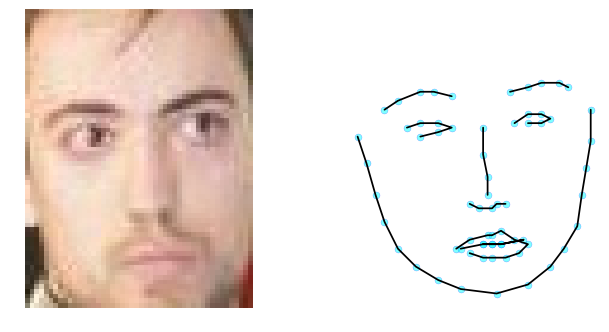

[6.4031242374328485, 8.06225774829855, 2.5, 3.0, 2.0, 2.0, 2.0, 2.0, 6.0, 27.018512172212592, 27.16615541441225, 12.041594578792296, 11.313708498984761, 16.0312195418814, 5.0, 19.026297590440446, 1.25, 1.25, 27.414640249326634, 1.0, 1.0, 28.040149785619906, 11.335784048754634, 5.0, 3.1622776601683795, 7.0, 7.0710678118654755, 7.0710678118654755, 5.70087712549569, 12.771944937361166, 24.748737341529164, 25.622255950637914, 8.5, 0.0]


In [0]:
import face_alignment
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from skimage import io

# Run the 3D face alignment on a test image, without CUDA.
fa = face_alignment.FaceAlignment(face_alignment.LandmarksType._3D, flip_input=False,device='cuda')

input = io.imread('/content/ivan_drawn.jpg')
preds = fa.get_landmarks(input)[-1]
h,w=input.shape[:2]
input1=np.ones([h,w,3])*255

#TODO: Make this nice
fig = plt.figure(figsize=plt.figaspect(0.5))
ax = fig.add_subplot(1, 2, 1)
ax.imshow(input)
ax.axis('off')
ax = fig.add_subplot(1, 2, 2)
surf = ax.scatter(preds[:,0],preds[:,1],c="cyan", alpha=.5, edgecolor= 'b')
ax.imshow(input1)
ax.plot(preds[0:17,0],preds[0:17,1]  ,color=  'black' )
ax.plot(preds[17:22,0],preds[17:22,1]  ,color=  'black' )
ax.plot(preds[22:27,0],preds[22:27,1]  ,color=  'black' )
ax.plot(preds[27:31,0],preds[27:31,1]  ,color=  'black' )
ax.plot(preds[31:36,0],preds[31:36,1]  ,color=  'black' )
ax.plot(preds[36:42,0],preds[36:42,1]  ,color=  'black' )
ax.plot(preds[42:48,0],preds[42:48,1]  ,color=  'black' )
ax.plot(preds[48:60,0],preds[48:60,1]  ,color=  'black' )
ax.plot(preds[60:68,0],preds[60:68,1]  ,color=  'black' ) 
#ax.set_xlim(ax.get_xlim()[::-1])
ax.axis('off')
plt.show()
ul=[(preds[37,0]+preds[38,0])/2,(preds[37,1]+preds[38,1])/2]
dl=[(preds[40,0]+preds[41,0])/2,(preds[40,1]+preds[41,1])/2]
ur=[(preds[43,0]+preds[44,0])/2,(preds[43,1]+preds[44,1])/2]
dr=[(preds[46,0]+preds[47,0])/2,(preds[46,1]+preds[47,1])/2]
A=[(ul[0]+dl[0])/2,(ul[1]+dl[1])/2]
B=[(ur[0]+dr[0])/2,(ur[1]+dr[1])/2]
C=[(preds[17,0]+preds[26,0])/2,(preds[17,1]+preds[26,1])/2]
D=[(preds[21,0]+preds[22,0])/2,(preds[21,1]+preds[22,1])/2]
E=[(preds[48,0]+preds[54,0])/2,(preds[48,1]+preds[54,1])/2]
land=[[17,36],[26,45],[ul,dl],[37,41],[38,40],[ur,dr],[43,47],[44,46],[33,51],
      [39,48],[42,54],[33,48],[33,54],[48,54],[51,57],[33,8],
      [ul,A],[dl,A],[48,A],[ur,B],[dr,B],[54,B],[48,54],[49,58],[53,55],[21,39],[22,42],[36,39],[42,45],
      [],[C,33],[D,33],[E,33],[62,66]]
landmark=[]
for i in range(34):
  if(i==22 or i==27 or i==28):
    dist=((preds[land[i][0],0]-preds[land[i][1],0])**2+(preds[land[i][0],1]-preds[land[i][1],1])**2)/2
    o=np.sqrt(dist)
    landmark.append(o)
  elif(i==29):
    landmark.append(landmark[28]+landmark[27])
  elif(i==2):
    dist=((ul[0]-dl[0])**2+(ul[1]-dl[1])**2)
    o=np.sqrt(dist)
    landmark.append(o)
  elif(i==5):
    dist=((ur[0]-dr[0])**2+(ur[1]-dr[1])**2)
    o=np.sqrt(dist)
    landmark.append(o)
  elif(i==16):
    dist=((ul[0]-A[0])**2+(ul[1]-A[1])**2)
    o=np.sqrt(dist)
    landmark.append(o)
  elif(i==17):
    dist=((dl[0]-A[0])**2+(dl[1]-A[1])**2)
    o=np.sqrt(dist)
    landmark.append(o)
  elif(i==18):
    dist=((preds[48,0]-A[0])**2+(preds[48,1]-A[1])**2)
    o=np.sqrt(dist)
    landmark.append(o)
  elif(i==19):
          dist=((ur[0]-B[0])**2+(ur[1]-B[1])**2)
          o=np.sqrt(dist)
          landmark.append(o)
  elif(i==20):
          dist=((dr[0]-B[0])**2+(dr[1]-B[1])**2)
          o=np.sqrt(dist)
          landmark.append(o)
  elif(i==21):
    dist=((preds[54,0]-B[0])**2+(preds[54,1]-B[1])**2)
    o=np.sqrt(dist)
    landmark.append(o)
  elif(i==30):
    dist=((C[0]-preds[33,0])**2+(C[1]-preds[33,1])**2)
    o=np.sqrt(dist)
    landmark.append(o)
  elif(i==31):
    dist=((D[0]-preds[33,0])**2+(D[1]-preds[33,1])**2)
    o=np.sqrt(dist)
    landmark.append(o)
  elif(i==32):
    dist=((E[0]-preds[33,0])**2+(E[1]-preds[33,1])**2)
    o=np.sqrt(dist)
    landmark.append(o)
  
  else:
    dist=((preds[land[i][0],0]-preds[land[i][1],0])**2+(preds[land[i][0],1]-preds[land[i][1],1])**2)
    o=np.sqrt(dist)
    landmark.append(o)
print(landmark)
    



In [0]:
len(landmark)

34

In [0]:
from google.colab import files
uploaded = files.upload()


Saving images.jpg to images.jpg


In [0]:
# Python program to check if a number is Kaprekar number or not 

import numpy as np

# Returns true if n is a Kaprekar number, else false 
def iskaprekar( n): 
    if n == 1 : 
        return True
    
    #Count number of digits in square 
    sq_n = n * n 
    count_digits = 1
    while not sq_n == 0 : 
        count_digits = count_digits + 1
        sq_n = sq_n / 10
    
    sq_n = n*n # Recompute square as it was changed 
    
    # Split the square at different poitns and see if sum 
    # of any pair of splitted numbers is equal to n. 
    r_digits = 0
    while r_digits< count_digits : 
        r_digits = r_digits + 1
        eq_parts = (int) (10** (r_digits))
        
        # To avoid numbers like 10, 100, 1000 (These are not 
        # Karprekar numbers 
        if eq_parts == n : 
            continue
        
        # Find sum of current parts and compare with n 
        
        sum = sq_n/eq_parts + sq_n % eq_parts 
        if sum == n : 
            return True
    
    # compare with original number 
    return False
    
# Driver method 
while i<1000 : 
    if (iskaprekar(i)) : 
        print (i,end=" ") 
    i = i + 1
# code contributed by Nikita Tiwari 


In [0]:
from keras.applications.inception_v3 import InceptionV3
from keras.preprocessing import image
from keras.models import Model
from keras.layers import Dense, GlobalAveragePooling2D
from keras import backend as K

base_model = InceptionV3(weights='imagenet', input_shape=(227,227),include_top=False)
x = base_model.output
x = GlobalAveragePooling2D()(x)
# let's add a fully-connected layer
x = Dense(1024, activation='relu')(x)
# and a logistic layer -- let's say we have 200 classes
predictions = Dense(200, activation='softmax')(x)

# this is the model we will train
model = Model(inputs=base_model.input, outputs=predictions)
print(model.summary())

ValueError: ignored

In [0]:
from keras.applications.inception_v3 import InceptionV3
from keras.preprocessing import image
from keras.models import Model
from keras.layers import Dense, GlobalAveragePooling2D
from keras import backend as K

# create the base pre-trained model
base_model = InceptionV3(weights='imagenet', include_top=False)

# add a global spatial average pooling layer
x = base_model.output
x = GlobalAveragePooling2D()(x)
# let's add a fully-connected layer
x = Dense(1024, activation='relu')(x)
# and a logistic layer -- let's say we have 200 classes
predictions = Dense(200, activation='softmax')(x)

# this is the model we will train
model = Model(inputs=base_model.input, outputs=predictions)

# first: train only the top layers (which were randomly initialized)
# i.e. freeze all convolutional InceptionV3 layers
for layer in base_model.layers:
    layer.trainable = False

# compile the model (should be done *after* setting layers to non-trainable)
model.compile(optimizer='rmsprop', loss='categorical_crossentropy')

# train the model on the new data for a few epochs
model.fit_generator(gen, samples_per_epoch=750,
                                  nb_epoch=80,
                                  validation_data=gen,
                                  nb_val_samples=250)

# at this point, the top layers are well trained and we can start fine-tuning
# convolutional layers from inception V3. We will freeze the bottom N layers
# and train the remaining top layers.

# let's visualize layer names and layer indices to see how many layers
# we should freeze:
for i, layer in enumerate(base_model.layers):
   print(i, layer.name)

# we chose to train the top 2 inception blocks, i.e. we will freeze
# the first 249 layers and unfreeze the rest:
for layer in model.layers[:249]:
   layer.trainable = False
for layer in model.layers[249:]:
   layer.trainable = True

# we need to recompile the model for these modifications to take effect
# we use SGD with a low learning rate
from keras.optimizers import SGD
model.compile(optimizer=SGD(lr=0.0001, momentum=0.9), loss='categorical_crossentropy')

# we train our model again (this time fine-tuning the top 2 inception blocks
# alongside the top Dense layers
model.fit_generator(...)

In [2]:
!wget https://pan.baidu.com/s/1jIJNg2q 

--2019-03-27 10:28:17--  https://pan.baidu.com/s/1jIJNg2q
Resolving pan.baidu.com (pan.baidu.com)... 111.206.37.70
Connecting to pan.baidu.com (pan.baidu.com)|111.206.37.70|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://pan.baidu.com/share/init?surl=jIJNg2q [following]
--2019-03-27 10:28:19--  https://pan.baidu.com/share/init?surl=jIJNg2q
Reusing existing connection to pan.baidu.com:443.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘1jIJNg2q’

1jIJNg2q                [  <=>               ]   9.71K  33.4KB/s    in 0.3s    

2019-03-27 10:28:20 (33.4 KB/s) - ‘1jIJNg2q’ saved [9940]



In [3]:
# -*- coding: utf-8 -*-
"""
Created on Fri Oct 21 19:02:31 2016

@author: dingning
"""
from __future__ import division
import os
from PIL import Image,ImageOps,ImageDraw
import numpy as np
from scipy import sqrt, pi, arctan2, io
from scipy.ndimage import uniform_filter
from sklearn.linear_model import Lasso,LinearRegression
from math import floor

class model_parameters(object):
    
    def __init__(self,
                 N=3,
                 alpha=0.001,
                 new_size=(400,400),
                 expand=50,
                 expand_rate=0.2,
                 orientations=4,
                 pixels_per_cell=3,
                 cells_per_block=2,
                 cells_per_side=1,
                 train_or_test='train',
                 hog_no_block=True,
                 demo=False):
        self.N = N
        self.alpha = alpha
        self.new_size=new_size
        self.expand =expand
        self.expand_rate = expand_rate
        self.orientations = orientations
        self.pixels_per_cell = pixels_per_cell
        self.cells_per_block = cells_per_block
        self.cells_per_side = cells_per_side
        self.train_or_test = train_or_test
        self.hog_no_block = hog_no_block
        self.demo = demo
        
    def show_parameters(self):
        print 'use data in trainset or testset:',self.train_or_test
        print 'the number of iterations:',self.N
        print 'the L1 regularization parameter alpha is:',self.alpha
        print 'the new image size used is:',self.new_size
        print 'how much to expand in data preparation:',self.expand
        print 'the rate of expand in modifing the bbox:',self.expand_rate
        print 'the number of divisions of gradient angle used by hog:',self.orientations
        print 'pixels per cell in hog descriptor:',self.pixels_per_cell
        print 'cells per side in hog decriptor:',self.cells_per_side
        print 'cells per bolck in hog descriptor:',self.cells_per_block
        print 'do not use the block when computing the hog:',self.hog_no_block
        
def train(parameters):
    
    '''
    the standard SDM training function
    ---------------------------------------------------------------------------
    INPUT:
        parameters: the model parameter object
    OUTPUT:
        coef: a numpy array of R
        inte: a numpy array of b
        initials: a numpy array containing a initial landmarks (without ravel)
    ---------------------------------------------------------------------------
    '''
    parameters.train_or_test = 'train'
    
    #show the parameters which will be used
    parameters.show_parameters()
    
    #get the image path list
    image_path_list = get_image_path_list(parameters)
    
    #get the ground truth bounding boxes
    bbox_dict = load_boxes(parameters)
    
    #compute the hog features of ture landmarks
    mark_list = []
    hog_list = []
    grey_list = []
    print 'computing the hog features for ture landmarks...........'
    for path in image_path_list:
        grey,mark = crop_and_resize_image(path[:10],bbox_dict[path],parameters)
        hog_list.append(hog(grey,mark,parameters))
        grey_list.append(grey)
        mark_list.append(mark.ravel())
        
    HOG_TRUE = np.array(hog_list)
    MARK_TRUE = np.array(mark_list)
    
    #compute the initial landmarks by mean
    initials = np.mean(MARK_TRUE,axis = 0).astype(int)
    MARK_x = np.array([initials.tolist()] * len(image_path_list))
    initials = initials.reshape(68,2)
    
    #training
    coef = []
    inte = []
    
    for i in range(parameters.N):
        
        print 'Iteration: ',i + 1
        
        #compute the delta x
        MARK_delta = MARK_TRUE - MARK_x
        
        #compute the hog features
        HOG_x = np.zeros_like(HOG_TRUE)
        for j in range(len(image_path_list)):
            if j+1 % 100 == 0: print 'already computed',j+1,'features'
            HOG_x[j,:] = hog(grey_list[j],MARK_x[j,:].reshape(68,2),parameters)
        
        #linear regression
        if parameters.alpha == 0:
            reg = LinearRegression(fit_intercept=False)
        else:
            reg = Lasso(alpha=parameters.alpha)
        print 'computing the lasso linear regression.......'
        reg.fit(HOG_x,MARK_delta)  
        coef.append(reg.coef_.T)
        inte.append(reg.intercept_.T)
        
        #compute the sparse rate
        sparse_rate = coef[-1][coef[-1]==0].size / coef[-1].size
        print 'the sparse rate of',i+1,'th R is:',sparse_rate        
        
        #compute new landmarks        
        MARK_x = MARK_x + np.matmul(HOG_x, coef[i]) + inte[i]
    
    coef = np.array(coef)
    inte = np.array(inte)
    io.savemat('train_data',{'R':coef,'B':inte,'I':initials})
    
    return coef,inte,initials
    
    

def test_for_one_image(coef,inte,path,bbox,initials,parameters):
    '''
    given the regressors, predicted the landmarks
    ---------------------------------------------------------------------------
    INPUT:
        coef: the R matrix
        inte: the b vector
        path: the image file name with extension
        bbox: the numpy array of bbox
        initials: the numpy array of initials landmarks
        parameters: model parameter object
    OUTPUT:
        mark_x: predicted landmarks
        mark_t: the true landmarks
        MSE: the mean square error of all the iterations
    ---------------------------------------------------------------------------
    '''
    parameters.train_or_test = 'test'                       
                           
    grey,mark_true = crop_and_resize_image(path[:10],bbox,parameters)
    mark_x = initials.astype(int)
    MSE = []
    
    for i in range(coef.shape[0]):
        hog_x = hog(grey,mark_x,parameters)
        mark_x = (mark_x.ravel() + np.matmul(hog_x,coef[i]).astype(float) + inte[i].astype(float)).reshape(68,2)
        MSE.append((abs(mark_x.astype(int) - mark_true)**2).sum() / len(mark_true))
        
    if parameters.demo:
        im = Image.fromarray(grey)
        draw = ImageDraw.Draw(im)
        width = 5
        for i in range(len(mark_x)):
            circle = [mark_x[i,0]-width,mark_x[i,1]-width,mark_x[i,0]+width,mark_x[i,1]+width]
            draw.ellipse(circle,fill = 'red')
    
        im.show()
    
        
    return mark_x.astype(int),mark_true,MSE



def get_image_path_list(parameters):
    '''
    get a list containing all the paths of images in the trainset
    ---------------------------------------------------------------------------
    INPUT:
        parameters: model parameter object
    OUTPUT:
        a list with all the images' paths
    ---------------------------------------------------------------------------
    '''
    folder_path = 'data/' + parameters.train_or_test + 'set/png'
    assert os.path.exists(folder_path)
    assert os.path.isdir(folder_path)
    print 'already get all the image path.'
    return os.listdir(folder_path)




def load_boxes(parameters):
    '''
    load the ground truth ground truth boxes coordinates from .mat file
    ---------------------------------------------------------------------------
    INPUT:
        parameters: model parameter object
    OUTPUT:
        a dict with all the ground truth bounding boxes coordinates
        key: a string of filename    ex: 'image_0122.png'
        value: a numpy array of boungding boxes
    ---------------------------------------------------------------------------
    '''
    file_path = 'data/bounding_boxes/bounding_boxes_lfpw_' + parameters.train_or_test + 'set.mat'
    assert os.path.exists(file_path)
    x = io.loadmat(file_path)['bounding_boxes'][0]
    x = [x[0][0] for x in x]
    print 'loading ground truth bboxes....................'
    return {x[i][0][0]:x[i][1][0] for i in range(len(x))}
    
    
def load_landmarks(image_name,parameters):
    '''
    load the landmarks coordinates from .pts file
    ---------------------------------------------------------------------------
    INPUT:
        image_name: a string without extension   ex: 'image_0122'
        parameters: model parameter object
    OUTPUT:
        a numpy array containing all the points
    ---------------------------------------------------------------------------
    '''   
    file_path = 'data/' + parameters.train_or_test + 'set/pts/' + image_name + '.pts'  
    assert os.path.exists(file_path)
    with open(file_path) as f: rows = [rows.strip() for rows in f]
    coords_set = [point.split() for point in rows[rows.index('{') + 1:rows.index('}')]]
    return np.array([list([float(point) for point in coords]) for coords in coords_set])
    



def compute_new_bbox(image_size,bbox,parameters):
    '''
    compute the expanded bbox
    a robust function to expand the crop image bbox even the original bbox is
    around the border of the image
    ---------------------------------------------------------------------------
    INPUT:
        image_size: a tuple   ex: (height,width)
        bbox: the ground_truth bounding boxes  ex:[x0,y0,x1,y1]
        parameters: model parameter object
    OUTPUT:
        new bbox: ex:[x0,y0,x1,y1]
    ---------------------------------------------------------------------------
    '''
    x_size,y_size = image_size
    bx0,by0,bx1,by1 = bbox
    bw = by1 - by0
    bh = bx1 - bx0
    if bw > bh:
        delta = parameters.expand_rate * bw
        if by1 + delta > y_size:
            nby1 = y_size
        else:
            nby1 = int(floor(by1 + delta))
        if by0 - delta < 0:
            nby0 = 0
        else:
            nby0 = int(floor(by0 - delta))
        new_w = nby1 - nby0
        delta_h = (new_w - bh) / 2
        if bx0 - delta_h < 0:
            nbx0 = 0
        else:
            nbx0 = int(floor(bx0 - delta_h))
        if bx1 + delta_h > x_size:
            nbx1 = x_size
        else:
            nbx1 = int(floor(bx1 + delta_h))
    else:
        delta = parameters.expand_rate * bh
        if bx1 + delta > x_size:
            nbx1 = x_size
        else:
            nbx1 = int(floor(bx1 + delta))
        if bx0 - delta < 0:
            nbx0 = 0
        else:
            nbx0 = int(floor(bx0 - delta))
        new_h = nbx1 - nbx0
        delta_w = (new_h - bw) / 2
        if by0 - delta_w < 0:
            nby0 = 0
        else:
            nby0 = int(floor(by0 - delta_w))
        if by1 + delta_w > y_size:
            nby1 = y_size
        else:
            nby1 = int(floor(by1 + delta_w))
    return nbx0,nby0,nbx1,nby1
    
def crop_and_resize_image(image_name,bbox,parameters):
    '''
    crop and resize the image given the ground truth bounding boxes
    also, compute the new coordinates according to transformation
    ---------------------------------------------------------------------------
    INPUT:
        image_name: a string without extension  ex: 'image_0007'
        bbox: the ground_truth bounding boxes  ex:[x0,y0,x1,y1]
        parameters: model parameter object
    OUTPUT:
        grey: a numpy array of grey image after crop and resize
        landmarks: new landmarks accordance with new image
    ---------------------------------------------------------------------------
    '''
    image_path = 'data/' + parameters.train_or_test + 'set/png/' + image_name + '.png'
    assert os.path.exists(image_path)
    im = Image.open(image_path)
    bbox = compute_new_bbox(im.size,bbox,parameters)
    im_crop = im.crop(bbox)
    Expand = parameters.expand
    im_expand = ImageOps.expand(im_crop,(Expand,Expand,Expand,Expand),fill = 'black')
    im_resize = im_expand.resize(parameters.new_size)
    grey = im_resize.convert('L')
    
    #compute the new landmarks according to transformation procedure
    landmarks = load_landmarks(image_name,parameters)
    landmarks = landmarks - (bbox[:2]) + Expand
    landmarks = landmarks * im_resize.size / im_expand.size
    
    return np.array(grey),landmarks.astype(int)


def hog(image, xys, parameters):
    '''
    Given a grey image in numpy array and a vector of sequence of coordinates,
    return the ndarray of hog feature vectors extract from given locations
    ---------------------------------------------------------------------------
    INPUT:
        image: grey image, numpy array, 8-bit
        xys: coordinates, numpy array, float
        parameters: model parameter object
    OUTPUT:
        features: ndarray of all the features extracted from locations in xy
    ---------------------------------------------------------------------------
    '''
    image = np.atleast_2d(image)    
    if image.ndim > 3: raise ValueError("Currently only supports grey-level images")


    #normalisation
    image = sqrt(image)
    
    
    #compute the gradients of the input grey image
    gx = np.zeros(image.shape)
    gy = np.zeros(image.shape)
    gx[:, :-1] = np.diff(image, n=1, axis=1)
    gy[:-1, :] = np.diff(image, n=1, axis=0)
    
    
    #compute the magnitude and orientation of gradients
    magnitude = sqrt(gx ** 2 + gy ** 2)
    orientation = arctan2(gy, (gx + 1e-15)) * (180 / pi) + 180

    #just for convinients, make the variables shorter
    r = parameters.pixels_per_cell * parameters.cells_per_side
    pc = parameters.pixels_per_cell
    eps = 1e-5
    
    #compute the orientation histogram
    orientation_histogram = np.zeros((len(xys), 
                                      parameters.cells_per_side*2, 
                                      parameters.cells_per_side*2, 
                                      parameters.orientations))    
    for j in range(len(xys)):        
        x, y = xys[j].astype(int)
        for i in range(parameters.orientations):
            # classify the orientation of the gradients
            temp_ori = np.where(orientation <= 180 / parameters.orientations * (i + 1) * 2,
                                orientation, 0)
            temp_ori = np.where(orientation > 180 / parameters.orientations * i * 2,
                                temp_ori, 0)
            # select magnitudes for those orientations
            cond2 = temp_ori > 0
            temp_mag = np.where(cond2, magnitude, 0)
        
            orientation_histogram[j,:,:,i] = uniform_filter(temp_mag, size=pc)[x-r+pc/2:x+r:pc, y-r+pc/2:y+r:pc].T
        
        if parameters.hog_no_block:
            orientation_histogram[j] /= sqrt(orientation_histogram[j].sum()**2 + eps)
    
    if parameters.hog_no_block: return orientation_histogram.ravel()
        
    
    #compute the block normalization
    n_blocks = parameters.cells_per_side * 2 - parameters.cells_per_block + 1
    cb = parameters.cells_per_block
    normalised_blocks = np.zeros((len(xys), n_blocks, n_blocks, cb, cb, parameters.orientations))
    
    for i in range(len(xys)):
        for x in range(n_blocks):
            for y in range(n_blocks):
                block = orientation_histogram[i,x:x + cb, y:y + cb, :]            
                normalised_blocks[i, x, y, :] = block / sqrt(block.sum() ** 2 + eps)
    
    return normalised_blocks.ravel()


def test_after_run_main(n):
    x,t,m = test_for_one_image(R,B,image_path_list[n],bbox_dict[image_path_list[n]],I,parameters)
    return x,t,m

if __name__ == '__main__':
    parameters = model_parameters()
    if os.path.exists('train_data.mat'):
        data = io.loadmat('train_data.mat')
        R = data['R']
        B = data['B']
        I = data['I']
    else:
        R,B,I = train(parameters)
    parameters.train_or_test = 'test'
    image_path_list = get_image_path_list(parameters)
    bbox_dict = load_boxes(parameters)
    


use data in trainset or testset: train
the number of iterations: 3
the L1 regularization parameter alpha is: 0.001
the new image size used is: (400, 400)
how much to expand in data preparation: 50
the rate of expand in modifing the bbox: 0.2
the number of divisions of gradient angle used by hog: 4
pixels per cell in hog descriptor: 3
cells per side in hog decriptor: 1
cells per bolck in hog descriptor: 2
do not use the block when computing the hog: True


AssertionError: ignored